In [4]:
# --- FASE 3: GUARDADO EFICIENTE ---

# Definir ruta de salida
output_path = '../data/processed/transactions_clean.parquet'

print(f"💾 Guardando dataset procesado en: {output_path}")
# Usamos parquet porque mantiene los tipos de datos y es muy rápido de leer
df.to_parquet(output_path, index=False)

print("✅ ¡Archivo guardado! Listo para el modelado.")

💾 Guardando dataset procesado en: ../data/processed/transactions_clean.parquet
✅ ¡Archivo guardado! Listo para el modelado.


⚙️ Creando features de comportamiento...


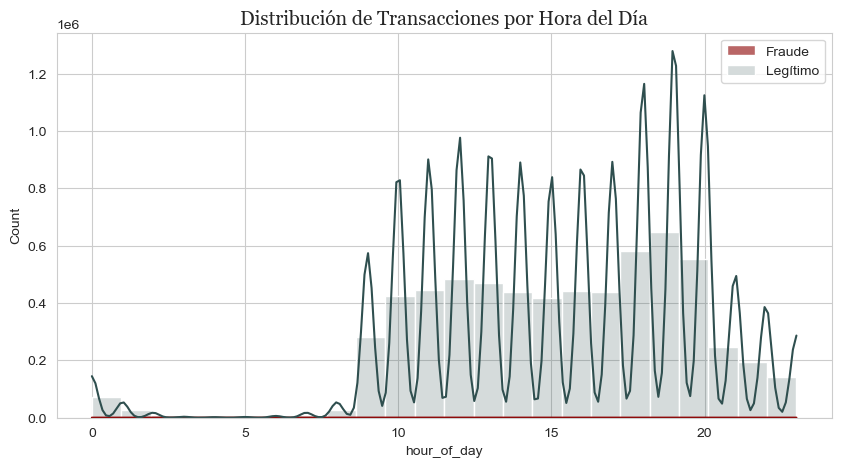

In [3]:
# --- FASE 1: LIMPIEZA INICIAL ---

# 1. Renombrar columnas para que sean fáciles de escribir
df = df.rename(columns={
    'oldbalanceOrg': 'old_balance_orig',
    'newbalanceOrig': 'new_balance_orig',
    'oldbalanceDest': 'old_balance_dest',
    'newbalanceDest': 'new_balance_dest',
    'nameOrig': 'name_orig',
    'nameDest': 'name_dest',
    'isFraud': 'is_fraud',
    'isFlaggedFraud': 'is_flagged_fraud'
})

# 2. Convertir 'step' (horas simuladas) a algo legible
# Asumimos que step 1 = hora 0.
df['hour_of_day'] = df['step'] % 24

# --- FASE 2: FEATURE ENGINEERING (VELOCIDAD) ---
print("⚙️ Creando features de comportamiento...")

# 3. Error en el balance (Indica si el dinero desapareció mágicamente)
# En una transacción legal: old_balance - amount = new_balance
df['error_balance_orig'] = df['new_balance_orig'] + df['amount'] - df['old_balance_orig']
df['error_balance_dest'] = df['old_balance_dest'] + df['amount'] - df['new_balance_dest']

# 4. Visualizar si el fraude ocurre a horas raras (Estilo Minimalista/Académico preliminar)
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['is_fraud']==1], x='hour_of_day', bins=24, kde=True, color='#8B0000', alpha=0.6, label='Fraude')
sns.histplot(data=df[df['is_fraud']==0], x='hour_of_day', bins=24, kde=True, color='#2F4F4F', alpha=0.2, label='Legítimo')
plt.title('Distribución de Transacciones por Hora del Día', fontsize=14, fontname='Georgia')
plt.legend()
plt.show()

In [1]:
# Contar fraudes
fraud_count = df['isFraud'].value_counts()
fraud_rate = (fraud_count[1] / len(df)) * 100

print(f"Total de transacciones: {len(df):,}")
print(f"Transacciones Legítimas (0): {fraud_count[0]:,}")
print(f"Transacciones Fraudulentas (1): {fraud_count[1]:,}")
print(f"⚠️ Tasa de Fraude: {fraud_rate:.3f}%")

# Visualizar el desbalanceo
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette=['#1f77b4', '#d62728'])
plt.title('Distribución de Fraude vs. No Fraude')
plt.yscale('log') # Usamos escala logarítmica porque el fraude es muy pequeño
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Para ver números completos, no científicos

# 1. Carga de Datos (Esto puede tardar unos segundos, son ~6 millones de filas)
print("⏳ Cargando dataset...")
df = pd.read_csv('../data/raw/transactions.csv')
print(f"✅ Dataset cargado con éxito. Dimensiones: {df.shape}")

# 2. Muestra las primeras 5 filas
display(df.head())

⏳ Cargando dataset...
✅ Dataset cargado con éxito. Dimensiones: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
